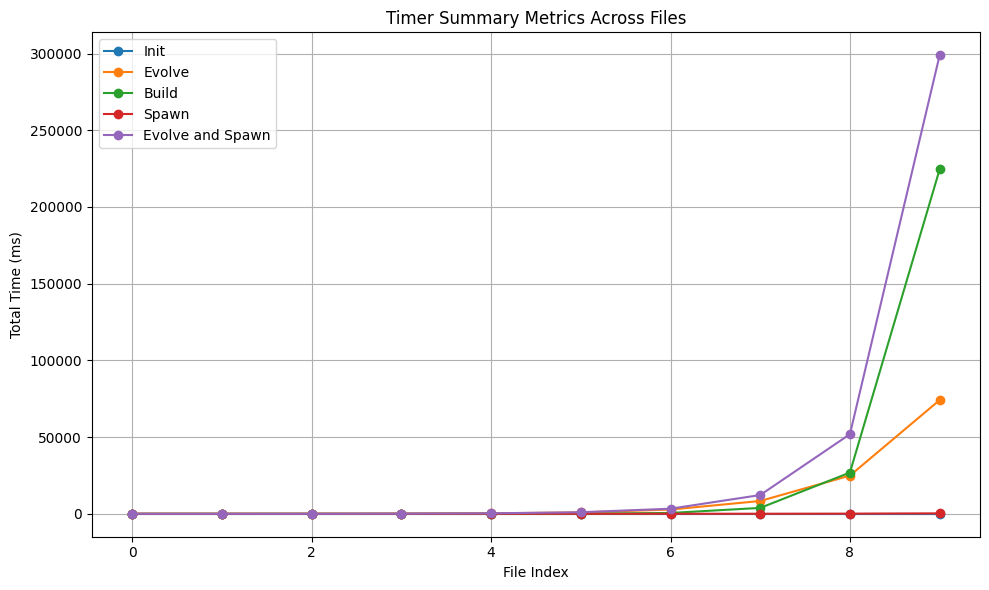

In [2]:
import matplotlib.pyplot as plt
import re

# Metrics we're interested in
metrics = ["Init", "Evolve", "Build", "Spawn", "Evolve and Spawn"]
data = {metric: [] for metric in metrics}

# Regex to extract: Metric: Total = number ms
pattern = re.compile(r'^(.*?): Total = (\d+) ms')

# Read each file and extract metrics
for i in range(10):
    with open(f'timer_summary_{i}_iterations.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            match = pattern.match(line.strip())
            if match:
                metric, total = match.groups()
                if metric in data:
                    data[metric].append(int(total))

# Plot
plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(data[metric], label=metric, marker='o')

plt.xlabel('File Index')
plt.ylabel('Total Time (ms)')
plt.title('Timer Summary Metrics Across Files')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()